## Read data

In [62]:
import numpy as np
from isaaclab.app import AppLauncher
import isaaclab.utils.math as math_utils
import torch
import matplotlib.pyplot as plt

motion_file = "./amp_loco_ablation_no_mc_backward.npy"
data = np.load(motion_file, allow_pickle=True).item()
joint_idx = [0, 3, 6, 9, 16, 17, 1, 4, 7, 10, 19, 20, 2, 15, 14, 22, 11, 12, 23, 45, 47, 49, 51, 53, 13, 24, 46, 48, 50, 52, 54]

In [61]:
data['joint_pos'][:, joint_idx].shape

torch.Size([1000, 31])

In [63]:
data = {
    "joint_pos": data["joint_pos"][:, joint_idx],
    "joint_vel": data["joint_vel"][:, joint_idx],
    "root_pos": data["root_pos"].squeeze(1),
    "root_rot": data["root_rot"].squeeze(1),
}
np.save('amp_loco_ablation_no_mc_backward_fix_idx.npy', data)

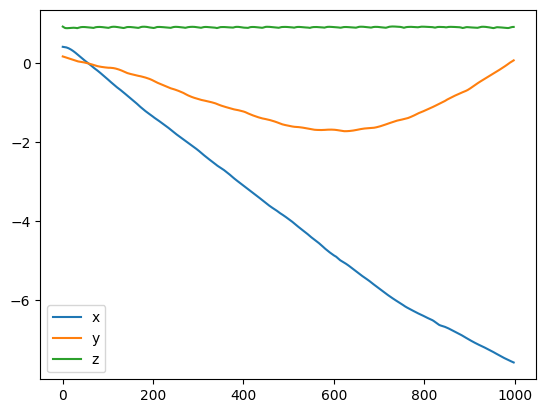

In [50]:
root_pos_np_cpu = data['root_pos'].cpu().numpy()
# root_vel_np_cpu = (root_pos_np_cpu[1:] - root_pos_np_cpu[:-1]) / (1 / 30)

plt.figure()
plt.plot(root_pos_np_cpu[0:999, 0])
plt.legend(['x', 'y', 'z'])
plt.show()


In [30]:
forward_data = {
    'joint_pos': data['joint_pos'][500:1000],
    'joint_vel': data['joint_vel'][500:1000],
    'root_pos': data['root_pos'][500:1000],
    'root_rot': data['root_rot'][500:1000]
}
backward_data = {
    'joint_pos': data['joint_pos'][:500],
    'joint_vel': data['joint_vel'][:500],
    'root_pos': data['root_pos'][:500],
    'root_rot': data['root_rot'][:500]
}

np.save('amp_loco_forward.npy', forward_data)
np.save('amp_loco_backward.npy', backward_data)


## Read ablation data

In [167]:
import numpy as np
from isaaclab.app import AppLauncher
import isaaclab.utils.math as math_utils
import torch
import matplotlib.pyplot as plt

motion_file = "./ablation_no_mc_forward_raw.npy"
data = np.load(motion_file, allow_pickle=True).item()
joint_idx = [0, 3, 6, 9, 18, 37, 1, 4, 7, 10, 21, 44, 2, 5, 8, 22, 11, 12, 23, 45, 47, 49, 51, 53, 13, 24, 46, 48, 50, 52, 54]

fix_idx_data = {
    "joint_pos": data['joint_pos'][:, joint_idx],
    "joint_vel": data['joint_vel'][:, joint_idx],
    "root_pos": data['root_pos'],
    "root_rot": data['root_rot']
}

np.save("./ablation_no_mc_forward_fix_idx.npy", fix_idx_data)

In [141]:
data

{'joint_pos': tensor([[-0.1405, -0.1304,  0.0025,  ..., -0.1156, -0.0529, -0.0921],
         [-0.1545, -0.1581,  0.0063,  ..., -0.1857, -0.1116, -0.1143],
         [-0.1993, -0.2139,  0.0116,  ..., -0.1665, -0.1285, -0.0642],
         ...,
         [ 0.0813, -0.0987, -0.0201,  ..., -0.3638, -1.7784,  1.5668],
         [ 0.0623, -0.0889, -0.0238,  ..., -0.3609, -1.7361,  1.5428],
         [-0.1536, -0.1534,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 'joint_vel': tensor([[ 1.5010,  0.3404,  0.0376,  ..., -8.6936, -3.6128, -6.2191],
         [-1.7014, -1.9677,  0.3219,  ..., -0.5344, -2.5262,  0.9642],
         [-2.4221, -3.0893,  0.1608,  ...,  1.7817, -0.1192,  2.9917],
         ...,
         [-0.9120,  0.5500, -0.1751,  ...,  0.1799,  2.1964, -0.8367],
         [-0.9479,  0.4834, -0.2096,  ...,  0.1383,  1.9902, -1.2924],
         [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 'root_pos': tensor([[[ 0.4046,  0.1613,

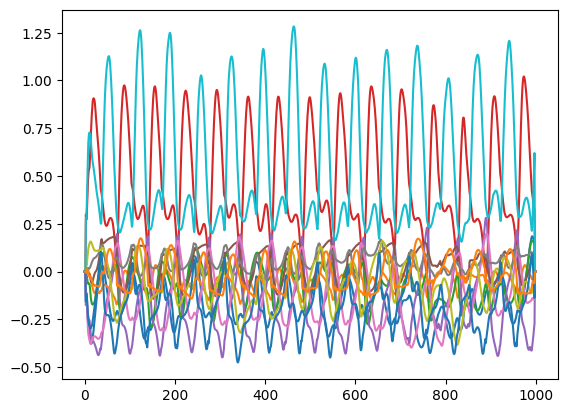

In [ ]:
joint_pos_data_np_cpu = data

plt.figure()
plt.plot(joint_pos_data_np_cpu[1:, :])
# plt.legend([])
plt.show()


## Try Relaxed DTW

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import gridspec

class RelaxedDTW:
    def __init__(self, seq1, seq2):
        self.seq1 = np.array(seq1)
        self.seq2 = np.array(seq2)
        self.n = len(self.seq1)
        self.m = len(self.seq2)
        self.D = None
        self.path = None

    def compute_matrix(self):
        n, m = self.n, self.m
        self.D = np.full((n + 1, m + 1), np.inf)
        self.D[0, :] = 0  # Relaxed Start
        
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                # 多维欧氏距离
                dist = np.linalg.norm(self.seq1[i - 1] - self.seq2[j - 1])
                self.D[i, j] = dist + min(self.D[i - 1, j],      # Insertion
                                          self.D[i, j - 1],      # Deletion
                                          self.D[i - 1, j - 1])  # Match
        return np.min(self.D[n, :])

    def get_optimal_path(self):
        if self.D is None:
            self.compute_matrix()
        n, m = self.n, self.m
        path = []
        
        # 1. 找到最佳终点 (Relaxed End)
        j_curr = np.argmin(self.D[n, :])
        i_curr = n
        path.append((i_curr - 1, j_curr - 1))

        # 2. 回溯
        while i_curr > 1:
            diag = self.D[i_curr - 1, j_curr - 1]
            up = self.D[i_curr - 1, j_curr]
            left = self.D[i_curr, j_curr - 1]
            
            if diag <= up and diag <= left:
                i_curr -= 1; j_curr -= 1
            elif up <= left:
                i_curr -= 1
            else:
                j_curr -= 1
            
            if j_curr < 1: j_curr = 1
            path.append((i_curr - 1, j_curr - 1))
            
        self.path = np.array(path[::-1])
        return self.path

    def plot_verification_multidim(self, max_dims_to_plot=3):
        """
        适用于多维数据的验证绘图。
        生成的图表包含：
        1. 左图：对齐路径矩阵 (Cost Matrix + Path)
        2. 右图：具体维度的波形对比 (按时间对齐后)
        """
        path = self.get_optimal_path()
        if path is None or len(path) == 0:
            print("Error: No path found.")
            return

        path_x = path[:, 0] # Seq1 indices
        path_y = path[:, 1] # Seq2 indices

        # 设置画布
        dims = self.seq1.shape[1]
        plot_dims = min(dims, max_dims_to_plot)
        
        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])

        # --- 图 1: 动态规划路径矩阵 (heatmap) ---
        ax0 = plt.subplot(gs[0])
        # 显示累积代价矩阵 D 的 log 值以便观察 (去掉第一行第一列的无穷大边界)
        D_vis = self.D[1:, 1:]
        # 防止 log(0) 报错，加一个小常数
        im = ax0.imshow(np.log(D_vis + 1), aspect='auto', origin='lower', cmap='viridis')
        
        # 画出红色对齐路径
        # 注意：imshow 的坐标系 x 是列(seq2), y 是行(seq1)
        ax0.plot(path_y, path_x, 'r-', linewidth=2, label='Optimal Path')
        
        ax0.set_title("DTW Alignment Path (Matrix View)")
        ax0.set_ylabel("Seq1 Index (Reference)")
        ax0.set_xlabel("Seq2 Index (Generated)")
        ax0.legend()
        plt.colorbar(im, ax=ax0, label='Log Accumulated Cost')

        # --- 图 2: 维度波形对比 ---
        ax1 = plt.subplot(gs[1])
        
        # 为了展示对齐效果，我们需要把 Seq2 根据 path "拉伸/压缩" 到 Seq1 的时间轴上
        # 或者更简单：直接画出两者随 "Path Step" 的变化
        
        # 这里我们简单地把 Seq1 和 "对齐后的 Seq2" 画在一起
        # 这种画法：X轴是 "Path Index" (对齐后的共同时间轴)
        
        steps = np.arange(len(path))
        
        colors = ['blue', 'green', 'purple', 'orange']
        
        for d in range(plot_dims):
            c = colors[d % len(colors)]
            # 取出 Seq1 在路径上的值
            val1 = self.seq1[path_x, d]
            # 取出 Seq2 在路径上的值
            val2 = self.seq2[path_y, d]
            
            # 为了避免线重叠看不清，给每一维加一个 offset 偏移量
            offset = d * 2.0 
            
            ax1.plot(steps, val1 + offset, '-', color=c, alpha=0.5, label=f'Dim {d} (Ref)' if d==0 else None)
            ax1.plot(steps, val2 + offset, '--', color=c, linewidth=1.5, label=f'Dim {d} (Gen)' if d==0 else None)
            
            # 标注维度名
            ax1.text(0, val1[0] + offset, f'Dim {d}', fontsize=9, fontweight='bold')

        ax1.set_title(f"Dimension-wise Match (First {plot_dims} dims)")
        ax1.set_xlabel("Alignment Steps")
        ax1.set_yticks([]) # 隐藏 Y 轴刻度，因为加了 offset
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

### DEMO

```python
# --- 模拟多维数据测试 ---

# 假设是 8 维的数据 (例如 8 个关节)
# 模拟数据
N = 50
t = np.linspace(0, 4*np.pi, N)
seq1_data = []
for i in range(8):
    # 每一维是不同频率的正弦波
    seq1_data.append(np.sin(t * (1 + i*0.1)) + i) # +i 只是为了让数值不同
seq1 = np.array(seq1_data).T # (50, 8)

# 生成 seq2: 
# 1. 加上开头静止数据 (Relaxed Start 测试)
# 2. 中间加噪声
# 3. 加上结尾多余数据 (Relaxed End 测试)
zeros = np.zeros((10, 8)) + np.arange(8) # 开头静止
noise_seq1 = seq1 + np.random.normal(0, 0.1, seq1.shape) # 中间匹配部分
extra = np.random.rand(15, 8) # 结尾乱码

seq2 = np.vstack((zeros, noise_seq1, extra)) # (75, 8)

# 运行
dtw = RelaxedDTW(seq1, seq2)
dist = dtw.compute_matrix()
print(f"Distance: {dist}")
dtw.plot_verification_multidim(max_dims_to_plot=4) # 只画前4维看看
```

### CODE

In [173]:
# ablation no mc backward

data_motion = np.load("./amp_loco_backward_50hz_clipped.npy", allow_pickle=True).item()
ablation_no_mc_motion = np.load("./ablation_no_mc_backward_fix_idx_clipped.npy", allow_pickle=True).item()

joint_pos_data_motion = data_motion['joint_pos'].cpu().numpy()[:, :12]
joint_pos_data_ablation_no_mc_motion = ablation_no_mc_motion['joint_pos'].cpu().numpy()[:, :12]

joint_pos_data_motion_dtw = joint_pos_data_motion # [:, (0, 1, 2, 3, 4, 5, 6)]
joint_pos_data_ablation_no_mc_motion_dtw = joint_pos_data_ablation_no_mc_motion # [:, (0, 1, 2, 3, 4, 5, 6)]

dtw_solver = RelaxedDTW(joint_pos_data_motion_dtw, joint_pos_data_ablation_no_mc_motion_dtw)
path = dtw_solver.get_optimal_path()
path_length = len(path)
print(f"Computed Distance: {dtw_solver.compute_matrix():.4f}")
print(f"Average Error: {dtw_solver.compute_matrix() / path_length:.4f}")
# dtw_solver.plot_verification_multidim()

Computed Distance: 95.2991
Average Error: 0.4560


In [176]:
# ablation no mc forward

data_motion = np.load("./amp_loco_forward_50hz_clipped.npy", allow_pickle=True).item()
ablation_no_mc_motion = np.load("./ablation_no_mc_forward_fix_idx_clipped.npy", allow_pickle=True).item()

joint_pos_data_motion = data_motion['joint_pos'].cpu().numpy()[:, :12]
joint_pos_data_ablation_no_mc_motion = ablation_no_mc_motion['joint_pos'].cpu().numpy()[:, :12]

joint_pos_data_motion_dtw = joint_pos_data_motion # [:, (0, 1, 2, 3, 4, 5, 6)]
joint_pos_data_ablation_no_mc_motion_dtw = joint_pos_data_ablation_no_mc_motion # [:, (0, 1, 2, 3, 4, 5, 6)]

dtw_solver = RelaxedDTW(joint_pos_data_motion_dtw, joint_pos_data_ablation_no_mc_motion_dtw)
path = dtw_solver.get_optimal_path()
path_length = len(path)
print(f"Computed Distance: {dtw_solver.compute_matrix():.4f}")
print(f"Average Error: {dtw_solver.compute_matrix() / path_length:.4f}")
# dtw_solver.plot_verification_multidim()

Computed Distance: 117.2015
Average Error: 0.5831


In [178]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 优化后的绘图代码
# def plot_joint_comparison(joint_pos_data_ablation_no_mc_motion, joint_pos_data_motion, 
#                           title="Joint Position Comparison", figsize=(15, 12)):
#     """
#     绘制关节位置对比图
    
#     Args:
#         joint_pos_data_ablation_no_mc_motion: 第一个数据集的关节位置数据
#         joint_pos_data_motion: 第二个数据集的关节位置数据
#         title: 图表标题
#         figsize: 图表大小
#     """
#     # 确保数据长度一致
#     min_length = min(len(joint_pos_data_ablation_no_mc_motion), len(joint_pos_data_motion))
#     data1 = joint_pos_data_ablation_no_mc_motion[:min_length]
#     data2 = joint_pos_data_motion[:min_length]
    
#     # 计算子图布局
#     total_joints = 12  # 4x3 = 12个关节
#     rows, cols = 4, 3
    
#     # 创建图表
#     fig, axes = plt.subplots(rows, cols, figsize=figsize)
#     fig.suptitle(title, fontsize=16, fontweight='bold')
    
#     # 扁平化axes数组以便迭代
#     axes = axes.flatten() if rows > 1 else [axes] if cols > 1 else [axes]
    
#     # 定义颜色和标签
#     colors = ['#2E86AB', '#A23B72']
#     labels = ['Ablation No MC', 'Original Motion']
#     linewidths = [1.5, 1.2]
    
#     idx = 0
#     for i in range(rows):
#         for j in range(cols):
#             ax = axes[idx]
            
#             # 绘制两条曲线
#             ax.plot(data1[:, idx], color=colors[0], label=labels[0], 
#                    linewidth=linewidths[0], alpha=0.8)
#             ax.plot(data2[:, idx], color=colors[1], label=labels[1], 
#                    linewidth=linewidths[1], alpha=0.8)
            
#             # 设置子图标题和样式
#             ax.set_title(f'Joint {idx + 1}', fontsize=10, fontweight='bold')
#             ax.grid(True, alpha=0.3)
#             ax.set_xlabel('Time Step', fontsize=8)
#             ax.set_ylabel('Position', fontsize=8)
            
#             # 只在第一行显示图例
#             if i == 0:
#                 ax.legend(loc='upper right', fontsize=8)
            
#             idx += 1
#             if idx >= total_joints:
#                 break
#         if idx >= total_joints:
#             break
    
#     # 调整布局
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.93)  # 为总标题留出空间
    
#     return fig, axes

# # 使用示例
# fig, axes = plot_joint_comparison(
#     joint_pos_data_ablation_no_mc_motion, 
#     joint_pos_data_motion,
#     title="Joint Position Comparison: Ablation vs Original"
# )
# plt.show()

## Clip motion data

In [168]:
import numpy as np


data = np.load("amp_loco_forward_50hz.npy", allow_pickle=True).item()
data_clipped = {
    "joint_pos": data["joint_pos"][20:220, :],
    "joint_vel": data["joint_vel"][20:220, :],
    "root_pos": data["root_pos"][20:220, :],
    "root_rot": data["root_rot"][20:220, :],
}
np.save("amp_loco_forward_50hz_clipped.npy", data_clipped)

In [169]:
import numpy as np


data = np.load("ablation_no_mc_forward_fix_idx.npy", allow_pickle=True).item()
data_clipped = {
    "joint_pos": data["joint_pos"][5:205, :],
    "joint_vel": data["joint_vel"][5:205, :],
    "root_pos": data["root_pos"][5:205, :],
    "root_rot": data["root_rot"][5:205, :],
}
np.save("ablation_no_mc_forward_fix_idx_clipped.npy", data_clipped)